# Practice 09 — CNN Pipeline

One pipeline for colour images, run with two models.

| Model | Weights |
|:---|:---|
| VGG-11 | trained from scratch |
| ResNet18 | pretrained on ImageNet, last block and classifier fine-tuned |

Both read the same loaders, so what separates the final scores is the pair of models, not the data.

| Step | What it produces |
|:---|:---|
| Data | train / validation / test split, augmented, wrapped in `DataLoader` |
| `train` / `evaluate` | the epoch loop and the no-grad evaluation, written once |
| Models | two `nn.Module`s returning logits |
| Diagnostics | learning curves, final test score, confusion matrix |

**Dataset.** CIFAR-10: 32×32 colour photographs in 10 classes, resized to 96×96.

---
## Step 0. Imports and Setup

In [1]:
import time

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['axes.unicode_minus'] = False

# a GPU is worth having here; on a CPU-only machine .to(device) is a no-op and the run takes minutes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


---
## Step 1. Data

Two transforms, one dataset.
Training images are cropped and flipped at random, which returns a different view of the same photograph
every epoch; evaluation has to be deterministic and gets neither.

| Set | Size | Source | Transform |
|:---|:---|:---|:---|
| Train | 10000 | training split | resize, crop, flip, normalize |
| Validation | 2000 | training split | resize, normalize |
| Test | 2000 | test split | resize, normalize |

Both models take ImageNet normalization, the statistics ResNet18 was pretrained under, so neither model
gets an input distribution the other did not see.

In [2]:
# published ImageNet statistics, the ones the pretrained weights were fitted under
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.Resize(96),
    transforms.RandomCrop(96, padding=8),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_eval = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

cifar_train_augmented = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
cifar_train_plain = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_eval)
cifar_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_eval)

# the validation images come out of the training split, so the test split stays untouched until the end
train_set = Subset(cifar_train_augmented, range(10000))
val_set   = Subset(cifar_train_plain, range(10000, 12000))
test_set  = Subset(cifar_test, range(2000))

train_loader = DataLoader(train_set, batch_size=64,  shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False)

class_names = cifar_test.classes
y_test = np.array(cifar_test.targets[:2000])

print(f'train: {len(train_set)}, val: {len(val_set)}, test: {len(test_set)}')
print(f'batches per epoch - train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

X_batch, Y_batch = next(iter(train_loader))
print(f'one batch - X {tuple(X_batch.shape)} {X_batch.dtype}, Y {tuple(Y_batch.shape)} {Y_batch.dtype}')

train: 10000, val: 2000, test: 2000
batches per epoch - train: 157, val: 16, test: 16
one batch - X (64, 3, 96, 96) torch.float32, Y (64,) torch.int64


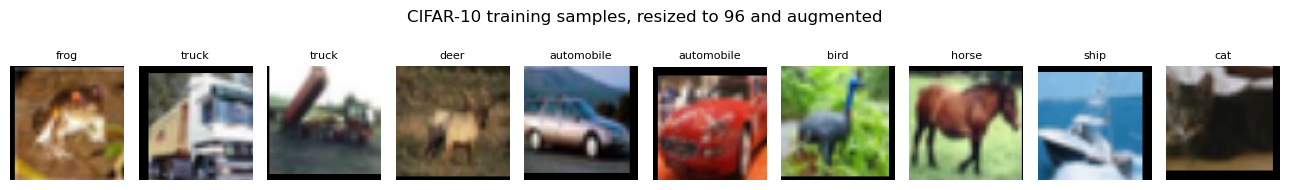

In [3]:
# turns a normalized (C, H, W) tensor back into an (H, W, C) array that imshow can display
def unnormalize(image_tensor):
    image = image_tensor.permute(1, 2, 0).numpy()
    image = image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(image, 0, 1)


fig, axes = plt.subplots(1, 10, figsize=(13, 1.8))
for i in range(10):
    image, label = train_set[i]
    axes[i].imshow(unnormalize(image))
    axes[i].set_title(class_names[label], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 training samples, resized to 96 and augmented', y=1.05)
plt.tight_layout(); plt.show()

---
## Step 2. `train` and `evaluate`

| Function | Returns |
|:---|:---|
| `train(model, train_loader, val_loader, optimizer, epochs, device)` | `(train_losses, train_accs, val_losses, val_accs)` |
| `evaluate(model, loader, device)` | `(loss, accuracy, y_pred)` |

Neither function names a model or a dataset, which is why the second model below needs no new training
code.
Monitoring runs on `val_loader` only; `test_loader` inside the loop would let the test set steer the
choice between the two models.

`evaluate` makes one pass over a loader with the gradient turned off.

In [4]:
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())

    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred

`train` runs the epoch loop and calls `evaluate` on `val_loader` after each epoch.

In [5]:
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            output = model(X_batch)               # logits, (batch, 10)
            loss = criterion(output, Y_batch)

            optimizer.zero_grad()                 # clear the accumulated gradients
            loss.backward()                       # autograd computes the gradients
            optimizer.step()                      # the optimizer updates the parameters

            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)

        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f'  Epoch {epoch+1:2d}/{epochs}  '
              f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
              f'train_acc={train_acc:.4f}  val_acc={val_acc:.4f}')
    return train_losses, train_accs, val_losses, val_accs

Both models are trained for the same number of epochs, with the same optimizer family.

In [6]:
epochs = 15

print(f'Loss      : {nn.CrossEntropyLoss()}')
print(f'Optimizer : SGD with momentum 0.9')
print(f'Epochs    : {epochs}')

Loss      : CrossEntropyLoss()
Optimizer : SGD with momentum 0.9
Epochs    : 15


---
## Step 3. VGGNet from Scratch

VGG makes depth the only variable: every convolution is 3x3 with stride 1, and reach comes from stacking
them rather than from widening the kernel.

Two stacked 3x3 layers cover the same 5x5 window as one 5x5 layer, with fewer weights and an extra
non-linearity between them.
Channels double at each pooling stage — resolution down, description up.

```
(N, 3, 96, 96)
  block1   conv 64                 pool -> 48
  block2   conv 128                pool -> 24
  block3   conv 256, conv 256      pool -> 12
  block4   conv 512, conv 512      pool -> 6
  block5   conv 512, conv 512      pool -> 3
  flatten 512*3*3 -> 512 -> 512 -> 10
```

Eight convolutions and three linear layers: the VGG-11 configuration, written out one layer at a time.

Two departures from the 2014 paper, both about getting a deep stack to train in a single run on this data.

| Here | In the paper |
|:---|:---|
| `BatchNorm2d` after every convolution | no normalization; deeper configurations were started from a shallower trained one |
| Classifier 512-512-10 | 4096-4096-1000, which on ten classes at 96x96 would hold most of the parameters |

The convolutional stack is unchanged, and that is where the VGG idea lives.

In [7]:
class VGG11(nn.Module):
    def __init__(self):
        super().__init__()
        # block 1 - one convolution, 96 -> 48
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2))

        # block 2 - one convolution, 48 -> 24
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2))

        # block 3 - two convolutions, 24 -> 12
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2))

        # block 4 - two convolutions, 12 -> 6
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2))

        # block 5 - two convolutions, 6 -> 3
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.MaxPool2d(2))

        self.classifier = nn.Sequential(
            nn.Linear(512 * 3 * 3, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 10))

        # He initialization, matched to the ReLU that follows each convolution
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = x.flatten(1)          # keep the batch axis, flatten the rest
        z = self.classifier(x)    # logits; the softmax is applied inside the loss
        return z


torch.manual_seed(42)
model_vgg = VGG11().to(device)
print(f'VGG-11 parameters: {sum(p.numel() for p in model_vgg.parameters()):,}')

VGG-11 parameters: 11,853,578


In [8]:
# the shape after each block, which is where 512 * 3 * 3 in the first linear layer comes from
x = torch.randn(1, 3, 96, 96).to(device)
print(f'input          : {tuple(x.shape)}')

x = model_vgg.block1(x)
print(f'after block1   : {tuple(x.shape)}')

x = model_vgg.block2(x)
print(f'after block2   : {tuple(x.shape)}')

x = model_vgg.block3(x)
print(f'after block3   : {tuple(x.shape)}')

x = model_vgg.block4(x)
print(f'after block4   : {tuple(x.shape)}')

x = model_vgg.block5(x)
print(f'after block5   : {tuple(x.shape)}')

print(f'after flatten  : {tuple(x.flatten(1).shape)}')

input          : (1, 3, 96, 96)


after block1   : (1, 64, 48, 48)
after block2   : (1, 128, 24, 24)
after block3   : (1, 256, 12, 12)
after block4   : (1, 512, 6, 6)
after block5   : (1, 512, 3, 3)
after flatten  : (1, 4608)


In [9]:
optimizer_vgg = torch.optim.SGD(model_vgg.parameters(), lr=0.01, momentum=0.9)

print(f'Training VGG-11 from scratch on {device} ...')
start = time.time()
train_losses_vgg, train_accs_vgg, val_losses_vgg, val_accs_vgg = train(
    model_vgg, train_loader, val_loader, optimizer_vgg, epochs=epochs, device=device)
print()
print(f'elapsed: {time.time() - start:.1f}s')
print(f'final val_acc={val_accs_vgg[-1]:.4f}  (best {max(val_accs_vgg):.4f})')

Training VGG-11 from scratch on cuda ...


  Epoch  1/15  train_loss=1.9942  val_loss=1.6949  train_acc=0.2438  val_acc=0.3595


  Epoch  2/15  train_loss=1.7306  val_loss=1.5371  train_acc=0.3498  val_acc=0.4235


  Epoch  3/15  train_loss=1.6090  val_loss=1.4017  train_acc=0.3970  val_acc=0.4960


  Epoch  4/15  train_loss=1.5299  val_loss=1.5521  train_acc=0.4390  val_acc=0.4420


...

  Epoch 11/15  train_loss=1.0596  val_loss=1.0069  train_acc=0.6318  val_acc=0.6535


  Epoch 12/15  train_loss=1.0097  val_loss=0.9363  train_acc=0.6448  val_acc=0.6770


  Epoch 13/15  train_loss=0.9701  val_loss=1.0158  train_acc=0.6658  val_acc=0.6380


  Epoch 14/15  train_loss=0.9400  val_loss=0.9700  train_acc=0.6788  val_acc=0.6650


  Epoch 15/15  train_loss=0.9062  val_loss=0.8761  train_acc=0.6924  val_acc=0.7050

elapsed: 186.6s
final val_acc=0.7050  (best 0.7050)


---
## Step 4. Pretrained ResNet18

`resnet18` arrives carrying weights fitted on ImageNet.
Its early layers hold general visual features that transfer as they are, while the deepest block and the
classifier are specific to the task they were trained on.

Only the latter two are trained here.

1. `requires_grad = False` on every parameter
2. `requires_grad = True` on `layer4`
3. `fc` replaced by a fresh `Linear(512, 10)`, trainable by construction

The optimizer receives the trainable parameters only, so the frozen ones are never updated.

In [10]:
torch.manual_seed(42)
model_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

for parameter in model_resnet.parameters():
    parameter.requires_grad = False
for parameter in model_resnet.layer4.parameters():
    parameter.requires_grad = True

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)   # 1000 ImageNet classes -> 10
model_resnet = model_resnet.to(device)

total_parameters = sum(p.numel() for p in model_resnet.parameters())
trainable_parameters = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f'total     parameters: {total_parameters:,}')
print(f'trainable parameters: {trainable_parameters:,}  ({trainable_parameters / total_parameters:.1%})')

# the classifier is random at this point, so the accuracy should sit near chance level, 10%
_, accuracy_before, _ = evaluate(model_resnet, val_loader, device)
print(f'val_acc before fine-tuning: {accuracy_before:.4f}')

total     parameters: 11,181,642
trainable parameters: 8,398,858  (75.1%)


val_acc before fine-tuning: 0.0795


In [11]:
trainable = [p for p in model_resnet.parameters() if p.requires_grad]
optimizer_resnet = torch.optim.SGD(trainable, lr=0.001, momentum=0.9)

print(f'Fine-tuning ResNet18 on {device} ...')
start = time.time()
train_losses_resnet, train_accs_resnet, val_losses_resnet, val_accs_resnet = train(
    model_resnet, train_loader, val_loader, optimizer_resnet, epochs=epochs, device=device)
print()
print(f'elapsed: {time.time() - start:.1f}s')
print(f'final val_acc={val_accs_resnet[-1]:.4f}  (best {max(val_accs_resnet):.4f})')

Fine-tuning ResNet18 on cuda ...


  Epoch  1/15  train_loss=1.3578  val_loss=0.8610  train_acc=0.5346  val_acc=0.7090


  Epoch  2/15  train_loss=0.7702  val_loss=0.6967  train_acc=0.7381  val_acc=0.7585


  Epoch  3/15  train_loss=0.6295  val_loss=0.6270  train_acc=0.7813  val_acc=0.7860


  Epoch  4/15  train_loss=0.5643  val_loss=0.5837  train_acc=0.8081  val_acc=0.8040


...

  Epoch 11/15  train_loss=0.3098  val_loss=0.4771  train_acc=0.8950  val_acc=0.8400


  Epoch 12/15  train_loss=0.2908  val_loss=0.4775  train_acc=0.9009  val_acc=0.8390


  Epoch 13/15  train_loss=0.2734  val_loss=0.4761  train_acc=0.9061  val_acc=0.8405


  Epoch 14/15  train_loss=0.2517  val_loss=0.4870  train_acc=0.9124  val_acc=0.8375


  Epoch 15/15  train_loss=0.2366  val_loss=0.4829  train_acc=0.9178  val_acc=0.8480

elapsed: 74.2s
final val_acc=0.8480  (best 0.8480)


---
## Step 5. Comparison

| | VGG-11 | ResNet18 |
|:---|:---|:---|
| Loaders, input size, augmentation, batch size | same | same |
| Epochs, optimizer family, seed | same | same |
| Model | 11 weight layers, from scratch | pretrained, `layer4` and `fc` trained |
| Learning rate | 0.01 | 0.001 |

> Two things differ, not one.
> A pretrained backbone at 0.01 would take large steps away from the features that make it worth using,
> so the smaller rate travels with the pretraining rather than being an independent choice.

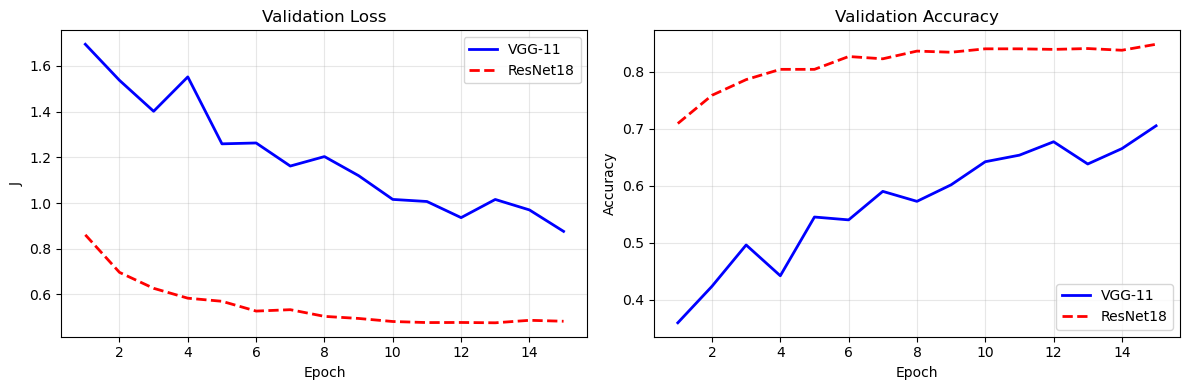

best val_acc - vgg: 0.7050, resnet: 0.8480


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, epochs + 1)

axes[0].plot(epochs_range, val_losses_vgg, 'b-',  linewidth=2, label='VGG-11')
axes[0].plot(epochs_range, val_losses_resnet, 'r--', linewidth=2, label='ResNet18')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('J')
axes[0].set_title('Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_accs_vgg, 'b-',  linewidth=2, label='VGG-11')
axes[1].plot(epochs_range, val_accs_resnet, 'r--', linewidth=2, label='ResNet18')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'best val_acc - vgg: {max(val_accs_vgg):.4f}, resnet: {max(val_accs_resnet):.4f}')

The VGG curves are still rising at the last epoch, and its train and validation accuracies sit on top of
each other.
That is a network short of training, not one that has overfitted — eleven weight layers learning from
10000 images need either more epochs or more data.

---
## Step 6. Final Test Evaluation

The choice between the two models has been made on the validation set, and nothing further will be decided
from the numbers below.
So the test split is read now, once, for each model.

In [13]:
test_loss_vgg, test_acc_vgg, y_pred_vgg = evaluate(model_vgg, test_loader, device)
test_loss_resnet, test_acc_resnet, y_pred_resnet = evaluate(model_resnet, test_loader, device)

print(f'VGG-11    test_loss={test_loss_vgg:.4f}  test_acc={test_acc_vgg:.4f}')
print(f'ResNet18  test_loss={test_loss_resnet:.4f}  test_acc={test_acc_resnet:.4f}')

VGG-11    test_loss=0.8694  test_acc=0.7080
ResNet18  test_loss=0.4761  test_acc=0.8350


---
## Step 7. Where the Errors Are

A single accuracy figure says how many photographs are wrong, not which ones.
`test_loader` was built with `shuffle=False`, so `y_pred_resnet` is aligned with `test_set` and each index
points back at its image.

- the first four misclassified test images, titled `True` / `Pred`
- the confusion matrix, whose off-diagonal entries name the pairs of classes being confused

misclassified: 330 of 2000 test images


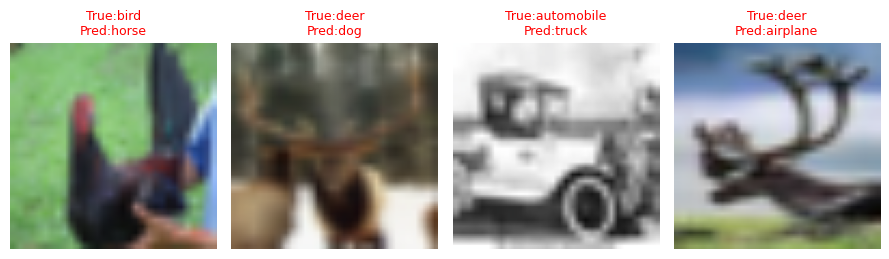

In [14]:
wrong_index = np.where(y_pred_resnet != y_test)[0]
print(f'misclassified: {len(wrong_index)} of {len(y_test)} test images')

fig, axes = plt.subplots(1, 4, figsize=(9, 2.8))
for i in range(4):
    index = wrong_index[i]
    image, _ = test_set[index]
    axes[i].imshow(unnormalize(image))
    axes[i].set_title(f'True:{class_names[y_test[index]]}\nPred:{class_names[y_pred_resnet[index]]}',
                      color='red', fontsize=9)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

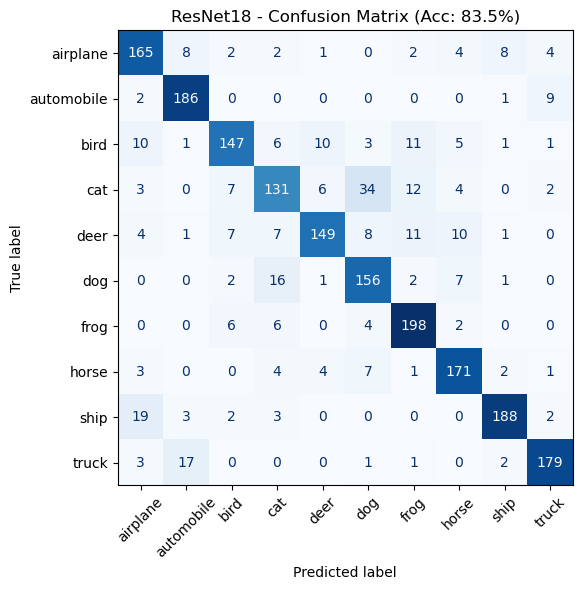

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_resnet), display_labels=class_names)
display_matrix.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'ResNet18 - Confusion Matrix (Acc: {test_acc_resnet:.1%})')
plt.tight_layout(); plt.show()

---
## Summary

- The pipeline is four pieces: loaders, `train` and `evaluate`, a model, diagnostics.
  Swapping the model changed nothing else.
- The frozen ImageNet layers were never updated, and the VGG stack never caught up with what they
  already knew within the same 15 epochs.
- The validation split steered the comparison; the test split was read after it was settled.

---
## Exercises

1. Unfreeze `layer3` as well and retrain.
   What does the trainable fraction become, and does the accuracy follow?
2. Drop the augmentation from `transform_train` and retrain VGG-11.
   Which curve moves, train or validation?
3. Replace `resnet18` with `resnet34` or `mobilenet_v2` and compare accuracy against run time.
4. Put your own photographs in `data/my_photos/<class>/<file>.jpg`, load them with
   `torchvision.datasets.ImageFolder`, and fine-tune the same ResNet18 on them.

In [16]:
# Write your code here